
# การขยาย Prognostic Model

การใช้งาน Prognostic Model แบบกำหนดเอง

ตัวอย่างนี้จะแสดงวิธีขยาย Earth2Studio โดยการสร้าง Prognostic Model แบบกำหนดเอง แล้วนำไปรันใน workflow ทั่วไปของระบบ

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- ข้อกำหนดของ API สำหรับ Prognostic Model
- วิธีสร้าง Prognostic Model แบบกำหนดเอง
- วิธีนำโมเดลนี้ไปรันใน workflow ที่มีอยู่


In [1]:
# /// script
# dependencies = [
#   "earth2studio @ git+https://github.com/NVIDIA/earth2studio.git",
#   "matplotlib",
# ]
# ///

## Prognostic Model แบบกำหนดเอง
ตามที่อธิบายไว้ใน `prognostic_model_userguide` ของคู่มือผู้ใช้ Earth2Studio กำหนดให้ Prognostic Model เป็นอินเทอร์เฟซที่เรียบง่ายผ่าน :py:class:`earth2studio.models.px.base.PrognosticModel` ซึ่งช่วยกำหนด API ที่จำเป็นสำหรับการสร้างโมเดลพยากรณ์แบบกำหนดเองของเราเอง

ในตัวอย่างนี้ เราจะสร้างโมเดลอย่างง่ายที่เพิ่ม Gaussian noise เข้าไปในสนามลมผิวพื้นในทุก step แม้จะไม่ใช่โมเดลที่ใช้งานจริง แต่เหมาะสำหรับสาธิต API ที่จำเป็นสำหรับ Prognostic Model

เริ่มจาก constructor ก่อน โดยทั่วไปโมเดลพยากรณ์ควรเป็นโมดูล PyTorch และควรมีเมธอด :py:obj:`to(device)` เพื่อย้ายโมเดลข้ามอุปกรณ์ต่าง ๆ ได้ หากโมเดลของคุณเขียนด้วย PyTorch อยู่แล้ว ส่วนนี้จะทำได้ไม่ยาก



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from collections import OrderedDict
from collections.abc import Generator, Iterator

import numpy as np
import torch

from earth2studio.models.batch import batch_coords, batch_func
from earth2studio.utils import handshake_coords, handshake_dim, handshake_size
from earth2studio.utils.type import CoordSystem


class CustomPrognostic(torch.nn.Module):
    """Custom prognostic model"""

    def __init__(self, noise_amplitude: float = 0.1):
        super().__init__()
        self.amp = noise_amplitude

    def input_coords(self) -> CoordSystem:
        """Input coordinate system of the prognostic model

        Returns
        -------
        CoordSystem
            Coordinate system dictionary
        """
        return OrderedDict(
            {
                "batch": np.empty(0),
                "lead_time": np.array([np.timedelta64(0, "h")]),
                "variable": np.array(["u10m", "v10m"]),
                "lat": np.linspace(90, -90, 721),
                "lon": np.linspace(0, 360, 1440, endpoint=False),
            }
        )

    @batch_coords()
    def output_coords(self, input_coords: CoordSystem) -> CoordSystem:
        """Output coordinate system of the prognostic model

        Parameters
        ----------
        input_coords : CoordSystem
            Input coordinate system to transform into output_coords

        Returns
        -------
        CoordSystem
            Coordinate system dictionary
        """
        # ตรวจสอบพิกัดอินพุตว่าถูกต้อง
        target_input_coords = self.input_coords()
        handshake_size(input_coords, "lead_time", 1)
        for i, (key, value) in enumerate(target_input_coords.items()):
            handshake_dim(input_coords, key, i)
            if key not in ["batch", "lead_time"]:
                handshake_coords(input_coords, target_input_coords, key)
        # สร้างพิกัดเอาต์พุต
        output_coords = OrderedDict(
            {
                "batch": np.empty(0),
                "lead_time": np.array([np.timedelta64(1, "h")]),
                "variable": np.array(["u10m", "v10m"]),
                "lat": np.linspace(90, -90, 721),
                "lon": np.linspace(0, 360, 1440, endpoint=False),
            }
        )
        output_coords["batch"] = input_coords["batch"]
        output_coords["lead_time"] = (
            output_coords["lead_time"] + input_coords["lead_time"]
        )
        return output_coords

    @batch_func()
    def __call__(
        self,
        x: torch.Tensor,
        coords: CoordSystem,
    ) -> tuple[torch.Tensor, CoordSystem]:
        """Runs prognostic model 1 step.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor
        coords : CoordSystem
            Input coordinate system
        """
        out_coords = self.output_coords(coords)
        out = x + self.amp * torch.rand_like(x)

        return out, out_coords

    @batch_func()
    def _default_generator(
        self, x: torch.Tensor, coords: CoordSystem
    ) -> Generator[tuple[torch.Tensor, CoordSystem], None, None]:
        """Create prognostic generator"""
        self.output_coords(coords)
        # ขั้นแรกควรเป็นสถานะเริ่มต้นเสมอ
        yield x, coords

        while True:
            coords = self.output_coords(coords)
            x = x + self.amp * torch.randn_like(x)
            yield x, coords

    def create_iterator(
        self, x: torch.Tensor, coords: CoordSystem
    ) -> Iterator[tuple[torch.Tensor, CoordSystem]]:
        """Creates a iterator which can be used to perform time-integration of the
        prognostic model. Will return the initial condition first (0th step).

        Parameters
        ----------
        x : torch.Tensor
            Input tensor
        coords : CoordSystem
            Input coordinate system
        """

        yield from self._default_generator(x, coords)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### พิกัดอินพุต/เอาต์พุต
การกำหนดระบบพิกัดอินพุต/เอาต์พุตเป็นสิ่งจำเป็นสำหรับโมเดลใดๆ ใน
Earth2Studio เนื่องจากนี่คือวิธีที่ทั้งแพ็กเกจและผู้ใช้สามารถเรียนรู้ว่าข้อมูลประเภทใด
โมเดลคาดหวัง การตรวจสอบให้แน่ใจว่าสิ่งนี้ถูกต้องจะเป็นการตั้งค่า Prognostic Model
ความสำเร็จ. ดูรายละเอียดที่ `coordinates_userguide`
ระบบพิกัด

สิ่งนี้ต้องการคำจำกัดความของสองฟังก์ชัน :py:func:`input_coords` และ
:py:func:`output_coords` :

* :py:func:`input_coords` : ฟังก์ชันที่ส่งคืนพิกัดอินพุตที่คาดหวัง
ระบบของโมเดล ควรส่งคืนพจนานุกรมใหม่ทุกครั้ง

* :py:func:`output_coords` : ฟังก์ชันที่ส่งคืนพิกัดเอาต์พุตที่คาดหวัง
ระบบของโมเดล *กำหนด* ระบบพิกัดอินพุต ฟังก์ชั่นนี้ก็ควรเช่นกัน
ตรวจสอบพจนานุกรมพิกัดอินพุต

ที่นี่ เรากำหนดพิกัดอินพุตเอาต์พุตให้เป็นลมที่พื้นผิวและให้โมเดล
ขนาดขั้นตอนเวลา 1 ชั่วโมง ดังนั้น :py:func:`output_coords` จะอัพเดต lead time ทีละตัว
ชั่วโมง.

<div class="alert alert-info"><h4>หมายเหตุ</h4><p>โปรดสังเกตเครื่องมือตกแต่ง :py:func:`batch_coords` ซึ่งจะทำให้การจัดการอัตโนมัติของ
ระบบพิกัด batched สำหรับรายละเอียดเพิ่มเติมเกี่ยวกับสิ่งนี้ โปรดดูที่ `batch_function_userguide`
ส่วนของคู่มือผู้ใช้</p></div>



### API ของ :py:func:`__call__`
ฟังก์ชันการโทรเป็นหนึ่งในสอง API หลักที่ใช้ในการโต้ตอบกับการพยากรณ์
แบบอย่าง. สิ่งแรกที่เราทำคือตรวจสอบระบบพิกัดของข้อมูลที่ป้อนเข้าให้แน่นอน
สิ่งที่โมเดลคาดหวัง ต่อไป เราจะดำเนินการส่งต่อโมเดลของเรา (ใช้สัญญาณรบกวน)
แล้วอัพเดตระบบพิกัดเอาท์พุต

<div class="alert alert-info"><h4>หมายเหตุ</h4><p>สังเกตการตกแต่ง :py:func:`batch_func` ซึ่งใช้ในการสร้าง batched
การดำเนินงานได้ง่ายขึ้น สำหรับรายละเอียดเพิ่มเติมเกี่ยวกับสิ่งนี้ โปรดดูที่ `batch_function_userguide`
ส่วนของคู่มือผู้ใช้</p></div>



### :py:func:`create_iterator` API
ฟังก์ชันการโทรมีประโยชน์สำหรับขั้นตอนเวลาเดียว อย่างไรก็ตาม การพยากรณ์เกิดขึ้น
อนุกรมเวลาซึ่งเสร็จสิ้นโดยใช้ตัววนซ้ำ สามารถทำได้โดยการสร้างเครื่องกำเนิดไฟฟ้า
ภายใต้ประทุนของการพยากรณ์

ตัวสร้างใน Python นั้นเป็นฟังก์ชันที่ส่งคืนตัววนซ้ำโดยใช้
คีย์เวิร์ด :py:obj:`yield` ในกรณีของการพยากรณ์ จะให้ผลลัพธ์เป็นขั้นตอนเดียว
การทำนายโมเดล โปรดทราบว่าการดำเนินการนี้ทำให้โมเดลสามารถควบคุมภายในของตนเองได้
สถานะภายในตัววนซ้ำโดยไม่ขึ้นกับ workflow

เนื่องจากโมเดลนี้เป็นแบบถดถอยอัตโนมัติ จึงสามารถจัดทำดัชนีตามเวลาได้ตลอดไปในทางทฤษฎี ดังนั้น,
เราทำให้เครื่องกำเนิดเป็นวงวนไม่สิ้นสุด โปรดทราบว่าเครื่องกำเนิดไฟฟ้าดำเนินการอยู่
ความต้องการ ดังนั้น infinite loop นี้จะไม่ทำให้โปรแกรมค้าง



<div class="alert alert-danger"><h4>คำเตือน</h4><p>มันเป็นความรับผิดชอบของการตรวจสอบโมเดลว่าเทนเซอร์อินพุตและพิกัดหรือไม่
ระบบใช้ได้จริง :py:func:`earth2studio.utils.coords.handshake_coords`
และ :py:func:`earth2studio.utils.coords.handshake_dim` สามารถช่วยทำให้สิ่งนี้ง่ายขึ้น</p></div>



## การเตรียมองค์ประกอบ
ด้วยการกำหนดการคาดการณ์แบบกำหนดเอง ตอนนี้จึงสามารถใช้งานได้ง่ายใน workflow มาตรฐาน ใน
ตัวอย่างนี้ เราจะใช้บิลด์ใน workflow :py:meth:`earth2studio.run.deterministic`



มาสร้างอินสแตนซ์ของคอมโพเนนต์ที่จำเป็นกัน

- Prognostic Model: ใช้การพยากรณ์แบบกำหนดเองของเราตามที่กำหนดไว้ด้านบน
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [3]:
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend

# สร้างโมเดลพยากรณ์
model = CustomPrognostic(noise_amplitude=10.0)

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## การรัน Workflow
เนื่องจากการพยากรณ์ตรงกับความต้องการของอินเทอร์เฟซ workflow จะดำเนินการ
เช่นเดียวกับรุ่นอื่นๆ



In [4]:
import earth2studio.run as run

nsteps = 24
io = run.deterministic(["2024-01-01"], nsteps, model, data, io)

print(io.root.tree())

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
2026-04-26 21:10:45.491 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 21:10:45.491 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data: 100%|██████████| 2/2 [00:00<00:00, 50.35it/s]


2026-04-26 21:10:45.831 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 407591936-940269
2026-04-26 21:10:45.855 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 406629528-962408
2026-04-26 21:10:45.880 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-26 21:10:45.886 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 25/25 [00:01<00:00, 22.08it/s]

2026-04-26 21:10:47.020 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (25,) timedelta64[h]
├── lon (1440,) float64
├── time (1,) datetime64[ns]
├── u10m (1, 25, 721, 1440) float32
└── v10m (1, 25, 721, 1440) float32



## การทำ Post-Processing
เพื่อยืนยันว่า Prognostic Model ของเราทำงานตามที่คาดไว้ เราควรเห็นฟิลด์ต่างๆ
มีเสียงดังมากขึ้นเรื่อยๆ เมื่อเวลาผ่านไป



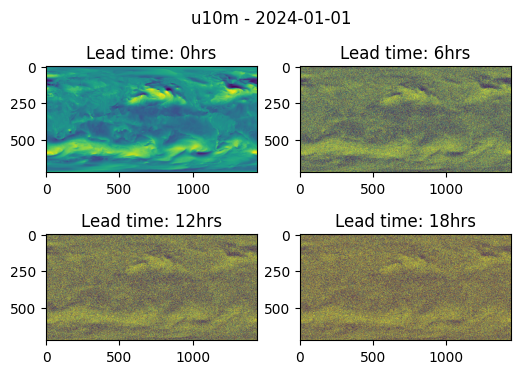

In [5]:
import matplotlib.pyplot as plt

forecast = "2024-01-01"
variable = "u10m"

plt.close("all")

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(2, 2, figsize=(6, 4))

# พล็อต u10m ทุก 6 ชั่วโมง
ax[0, 0].imshow(io[variable][0, 0], vmin=-20, vmax=20)
ax[0, 1].imshow(io[variable][0, 6], vmin=-20, vmax=20)
ax[1, 0].imshow(io[variable][0, 12], vmin=-20, vmax=20)
ax[1, 1].imshow(io[variable][0, 18], vmin=-20, vmax=20)


# ตั้งชื่อเรื่อง
plt.suptitle(f"{variable} - {forecast}")
times = (
    io["lead_time"][:].astype("timedelta64[ns]").astype("timedelta64[h]").astype(int)
)
ax[0, 0].set_title(f"Lead time: {times[0]}hrs")
ax[0, 1].set_title(f"Lead time: {times[6]}hrs")
ax[1, 0].set_title(f"Lead time: {times[12]}hrs")
ax[1, 1].set_title(f"Lead time: {times[18]}hrs")

plt.savefig("outputs/01_custom_prognostic_prediction.jpg", bbox_inches="tight")